In [ ]:
#!pip install --upgrade numpy --quiet

#!pip install surprise scikit-surprise lightfm gradio --quiet

In [ ]:
!pip install numpy==1.25.2 --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 27.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
arviz 0.22.0 requires numpy>=1.26.0, but you have numpy 1.25.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 1.25.2 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.25.2 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.25.2 which is incompatible.
blosc2 3.7.0 requires numpy>=1.26, but you have numpy 1.25.2 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.25.2 which is incompatible.
xarray 2025.7.1 requires numpy>=1.26, but you have numpy 1.25.2 which is incompatible.
opencv-python-headless 4.12.0.88 requires nu

In [ ]:
!pip install --no-cache-dir scikit-surprise --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


restart the session

In [ ]:
!pip install lightfm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lightfm: filename=lightfm-1.17-cp311-cp311-linux_x86_64.whl size=831129 sha256=f8f6a29b2958e7433f1cdc04f1ea8231c386f615151dab0b38ee3d5c5995fc78
  Stored in directory: /root/.cache/pip/wheels/b9/0d/8a/0729d2e6e3ca2a898ba55201f905da7db3f838a33df5b3fcdd
Successfully built lightfm


In [ ]:
import numpy as np
from surprise import Dataset, Reader, SVD, KNNBasic


In [ ]:

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import train_test_split
from lightfm import LightFM

# For reproducibility
SEED = 42
np.random.seed(SEED)

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Task 1

In [ ]:
movies = pd.read_csv(os.path.join(DATA_DIR, "movies_metadata.csv"), low_memory=False)
credits = pd.read_csv(os.path.join(DATA_DIR, "credits.csv"))
keywords = pd.read_csv(os.path.join(DATA_DIR, "keywords.csv"))
links = pd.read_csv(os.path.join(DATA_DIR, "links.csv"))
ratings = pd.read_csv(os.path.join(DATA_DIR, "ratings_small.csv"))  # start small

print(movies.shape, credits.shape, keywords.shape, links.shape, ratings.shape)

(45466, 24) (45476, 3) (46419, 2) (45843, 3) (100004, 4)


In [ ]:
import json, ast
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Helper funcs
def safe_parse_list_of_dicts(text, key="name"):
    if pd.isna(text):
        return []
    try:
        data = json.loads(text)
    except Exception:
        try:
            data = ast.literal_eval(text)
        except Exception:
            return []
    if isinstance(data, list):
        values = []
        for el in data:
            if isinstance(el, dict) and key in el:
                values.append(el.get(key))
        return values
    return []

def to_datetime_from_unix(s):
    return pd.to_datetime(s, unit="s", origin='unix', errors="coerce")

# Initial shapes
init_shapes = {
    "movies": movies.shape,
    "credits": credits.shape,
    "keywords": keywords.shape,
    "links": links.shape,
    "ratings": ratings.shape
}
print("Initial shapes (rows, cols):")
for k,v in init_shapes.items():
    print(f"  {k}: {v}")
print()

# Clean IDs
def clean_id_col(df, col="id"):
    before = df.shape[0]
    df[col] = pd.to_numeric(df[col], errors="coerce")
    after_dropna = df.dropna(subset=[col]).shape[0]
    return before, after_dropna

counts = {}
for name, df in [("movies", movies), ("credits", credits), ("keywords", keywords)]:
    before, after = clean_id_col(df, "id")
    counts[name] = {"before_rows": before, "after_numeric_id_rows": after}
    df.dropna(subset=["id"], inplace=True)
    df["id"] = df["id"].astype(int)

links_before = links.shape[0]
links["tmdbId"] = pd.to_numeric(links["tmdbId"], errors="coerce")
links["movieId"] = pd.to_numeric(links["movieId"], errors="coerce")
links.dropna(subset=["tmdbId","movieId"], inplace=True)
links["tmdbId"] = links["tmdbId"].astype(int)
links["movieId"] = links["movieId"].astype(int)
counts["links"] = {"before_rows": links_before, "after_numeric_rows": links.shape[0]}

ratings_before = ratings.shape[0]
ratings["movieId"] = pd.to_numeric(ratings["movieId"], errors="coerce")
ratings["userId"] = pd.to_numeric(ratings["userId"], errors="coerce")
ratings.dropna(subset=["movieId","userId","rating"], inplace=True)
ratings["movieId"] = ratings["movieId"].astype(int)
ratings["userId"] = ratings["userId"].astype(int)
counts["ratings"] = {"before_rows": ratings_before, "after_numeric_rows": ratings.shape[0]}

print("Rows before/after basic ID cleaning:")
for k,v in counts.items():
    print(f"  {k}: {v}")
print()

# Metadata availability
movies_cnt = movies.shape[0]
has_credits = movies["id"].isin(credits["id"]).sum()
has_keywords = movies["id"].isin(keywords["id"]).sum()
print(f"Movies total: {movies_cnt}")
print(f"  with credits metadata: {has_credits} ({has_credits/movies_cnt:.2%})")
print(f"  with keywords metadata: {has_keywords} ({has_keywords/movies_cnt:.2%})")
print()

# Merge metadata
movies_meta = movies.merge(credits[['id','cast','crew']], on="id", how="left")
movies_meta = movies_meta.merge(keywords[['id','keywords']], on="id", how="left")

print("After merging metadata:")
print("  movies_meta shape:", movies_meta.shape)
print("  movies with cast info:", movies_meta['cast'].notna().sum())
print("  movies with keywords:", movies_meta['keywords'].notna().sum())
print()

# Map ratings to metadata
ratings_before_map = ratings.shape[0]
ratings_linked = ratings.merge(links[['movieId','tmdbId']], on='movieId', how='left')
mapped = ratings_linked['tmdbId'].notna().sum()
print(f"Ratings total: {ratings_before_map}")
print(f"  ratings with tmdbId via links: {mapped} ({mapped/ratings_before_map:.2%})")

ratings_with_meta = ratings_linked.merge(movies_meta, left_on='tmdbId', right_on='id', how='left')
with_meta = ratings_with_meta['title'].notna().sum()
print(f"  ratings mapping to movie metadata: {with_meta} ({with_meta/ratings_before_map:.2%})")
print()

summary_rows = [
    ("movies_raw_rows", init_shapes['movies'][0]),
    ("movies_after_id_clean", movies.shape[0]),
    ("credits_raw_rows", init_shapes['credits'][0]),
    ("credits_after_id_clean", credits.shape[0]),
    ("keywords_raw_rows", init_shapes['keywords'][0]),
    ("keywords_after_id_clean", keywords.shape[0]),
    ("links_raw_rows", init_shapes['links'][0]),
    ("links_after_id_clean", links.shape[0]),
    ("ratings_raw_rows", init_shapes['ratings'][0]),
    ("ratings_after_id_clean", ratings.shape[0]),
    ("ratings_with_tmdbId", mapped),
    ("ratings_with_movie_metadata", with_meta),
]
summary_df = pd.DataFrame(summary_rows, columns=["step","rows"])
display(summary_df)

# Parse genres/countries
movies_meta['genres_list'] = movies_meta['genres'].apply(lambda x: safe_parse_list_of_dicts(x, key="name"))
movies_meta['prod_countries_list'] = movies_meta.get('production_countries', pd.Series(["[]"]*len(movies_meta))).apply(lambda x: safe_parse_list_of_dicts(x, key="name"))
if 'original_language' not in movies_meta.columns and 'original_language' in movies.columns:
    movies_meta['original_language'] = movies['original_language']

ratings_ts = ratings_with_meta.copy()
if 'timestamp' in ratings_ts.columns:
    ratings_ts['rating_ts'] = to_datetime_from_unix(ratings_ts['timestamp'])
else:
    ratings_ts['rating_ts'] = pd.NaT

Initial shapes (rows, cols):
  movies: (45466, 24)
  credits: (45476, 3)
  keywords: (46419, 2)
  links: (45843, 3)
  ratings: (100004, 4)

Rows before/after basic ID cleaning:
  movies: {'before_rows': 45466, 'after_numeric_id_rows': 45463}
  credits: {'before_rows': 45476, 'after_numeric_id_rows': 45476}
  keywords: {'before_rows': 46419, 'after_numeric_id_rows': 46419}
  links: {'before_rows': 45843, 'after_numeric_rows': 45624}
  ratings: {'before_rows': 100004, 'after_numeric_rows': 100004}

Movies total: 45463
  with credits metadata: 45462 (100.00%)
  with keywords metadata: 45462 (100.00%)

After merging metadata:
  movies_meta shape: (46629, 27)
  movies with cast info: 46628
  movies with keywords: 46628

Ratings total: 100004
  ratings with tmdbId via links: 99898 (99.89%)
  ratings mapping to movie metadata: 100122 (100.12%)



,step,rows
0,movies_raw_rows,45466
1,movies_after_id_clean,45463
2,credits_raw_rows,45476
3,credits_after_id_clean,45476
4,keywords_raw_rows,46419
5,keywords_after_id_clean,46419
6,links_raw_rows,45843
7,links_after_id_clean,45624
8,ratings_raw_rows,100004
9,ratings_after_id_clean,100004


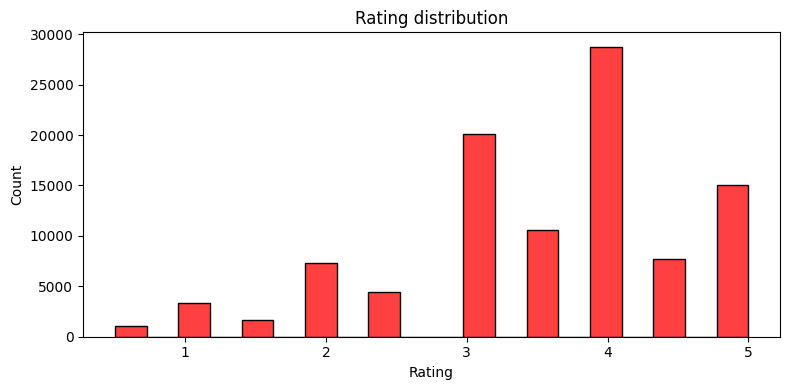

Rating stats:
count    100004.000000
mean          3.543608
std           1.058064
min           0.500000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64



In [ ]:
#Rating distribution
plt.figure(figsize=(8,4))
sns.histplot(ratings['rating'], bins=20, kde=False, color='red')
plt.title("Rating distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Rating stats:")
print(ratings['rating'].describe())
print()

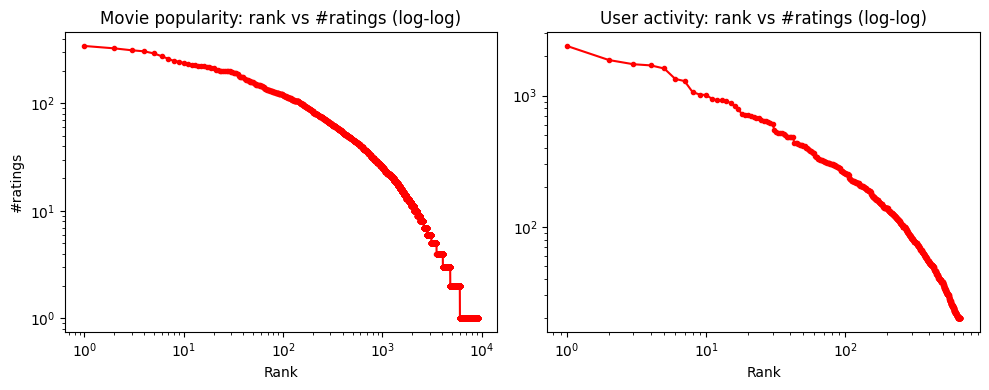

In [ ]:
# Long-tail
user_counts = ratings.groupby('userId').size().sort_values(ascending=False)
movie_counts = ratings.groupby('movieId').size().sort_values(ascending=False)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.loglog(range(1, len(movie_counts)+1), movie_counts.values, marker='.', c='red')
plt.title("Movie popularity: rank vs #ratings (log-log)")
plt.xlabel("Rank")
plt.ylabel("#ratings")
plt.subplot(1,2,2)
plt.loglog(range(1, len(user_counts)+1), user_counts.values, marker='.', c='red')
plt.title("User activity: rank vs #ratings (log-log)")
plt.xlabel("Rank")
plt.tight_layout()
plt.show()

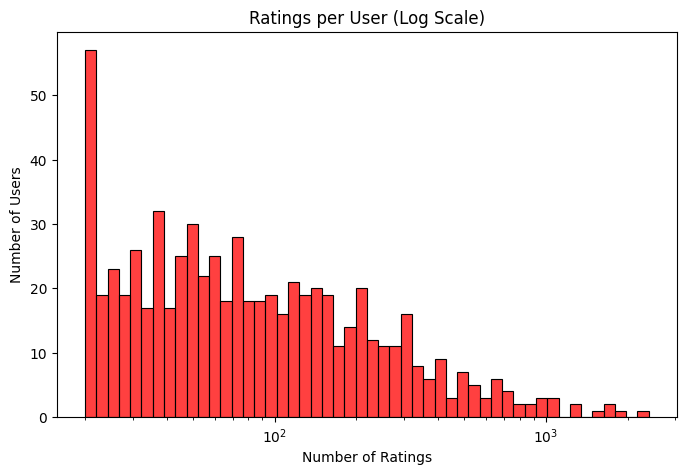

In [ ]:
# Ratings per user
user_counts = ratings.groupby('userId').size()
plt.figure(figsize=(8,5))
sns.histplot(user_counts, bins=50, log_scale=(True, False), color='red')
plt.title("Ratings per User (Log Scale)")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

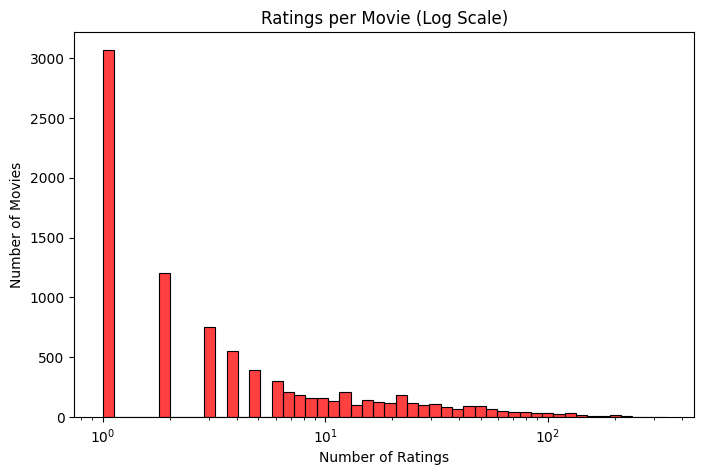

In [ ]:
# Ratings per movie
movie_counts = ratings.groupby('movieId').size()
plt.figure(figsize=(8,5))
sns.histplot(movie_counts, bins=50, log_scale=(True, False), color='red')
plt.title("Ratings per Movie (Log Scale)")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.show()

Density: 0.016439  -> Sparsity 98.3561%



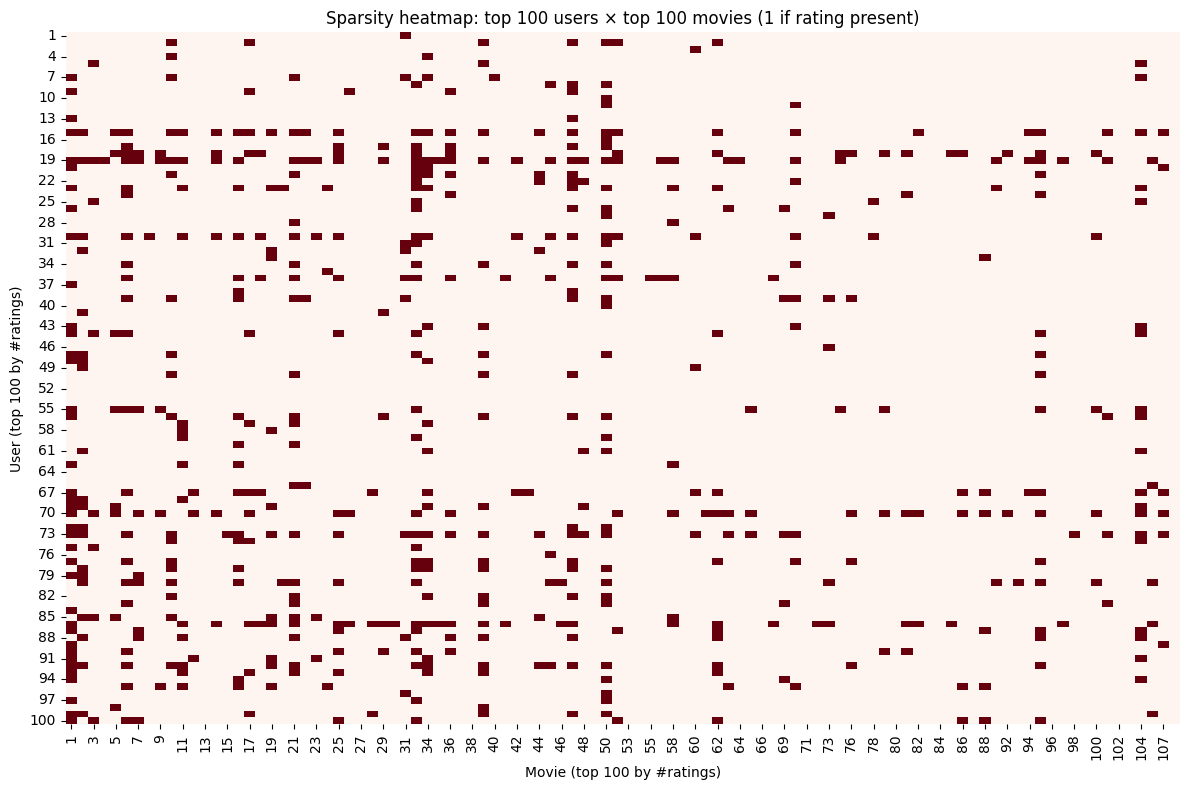

In [ ]:
#  Sparsity heatmap
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_interactions = len(ratings)
density = n_interactions / (n_users * n_movies)
print(f"Density: {density:.6f}  -> Sparsity {(1-density):.4%}")
print()

top_u = user_counts.head(100).index.tolist()
top_m = movie_counts.head(100).index.tolist()
sub = ratings[(ratings['userId'].isin(top_u)) & (ratings['movieId'].isin(top_m))]
pivot = pd.pivot_table(sub, index='userId', columns='movieId', values='rating', aggfunc='size', fill_value=0)
pivot = pivot.reindex(index=top_u, columns=top_m, fill_value=0)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='Reds', cbar=False)
plt.title("Sparsity heatmap: top 100 users × top 100 movies (1 if rating present)")
plt.xlabel("Movie (top 100 by #ratings)")
plt.ylabel("User (top 100 by #ratings)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3779833842.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = ratings_ts['rating'].resample('M').count()
/tmp/ipython-input-3779833842.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean = ratings_ts['rating'].resample('M').mean()


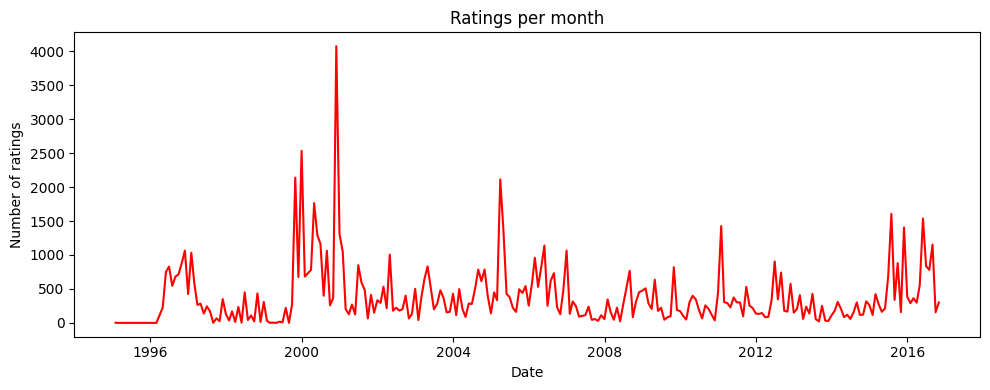

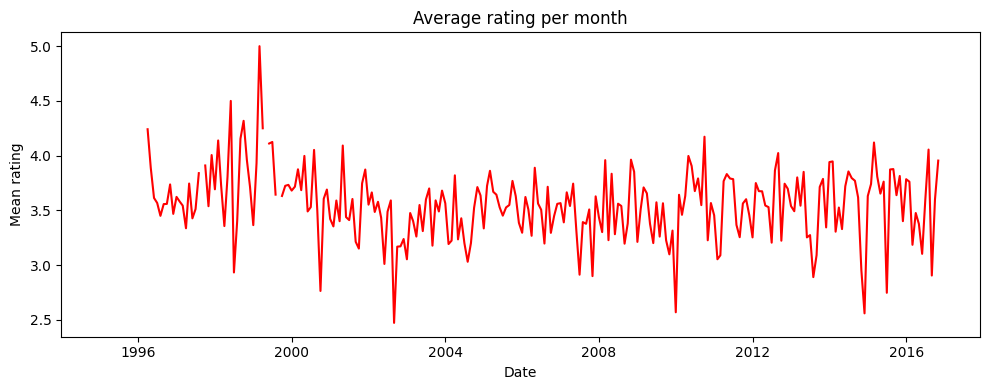

In [ ]:
#  Temporal dynamics
if ratings_ts['rating_ts'].notna().sum() > 0:
    ratings_ts = ratings_ts[ratings_ts['rating_ts'].notna()].copy()
    ratings_ts.set_index('rating_ts', inplace=True)
    monthly_counts = ratings_ts['rating'].resample('M').count()
    monthly_mean = ratings_ts['rating'].resample('M').mean()

    plt.figure(figsize=(10,4))
    plt.plot(monthly_counts.index, monthly_counts.values, color='red')
    plt.title("Ratings per month")
    plt.xlabel("Date")
    plt.ylabel("Number of ratings")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(monthly_mean.index, monthly_mean.values, color='red')
    plt.title("Average rating per month")
    plt.xlabel("Date")
    plt.ylabel("Mean rating")
    plt.tight_layout()
    plt.show()

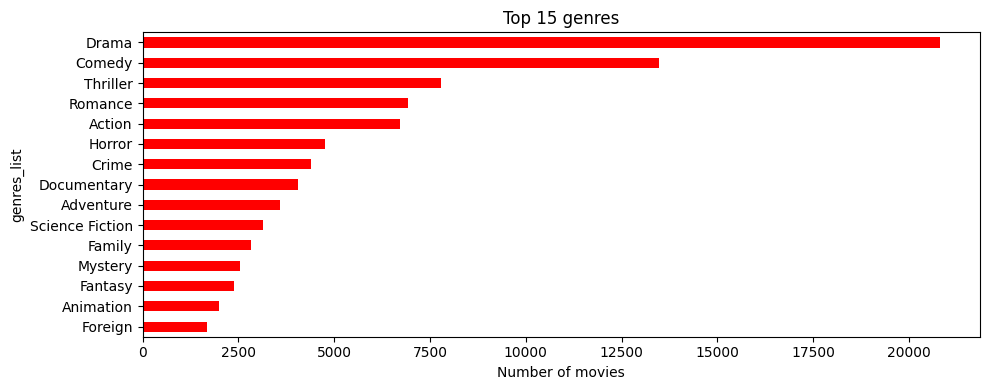

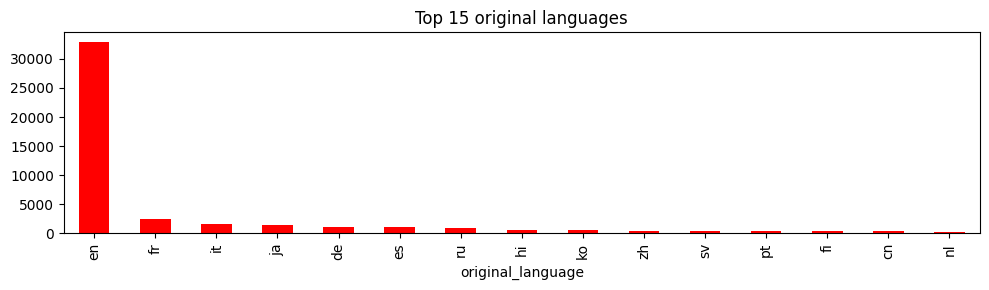

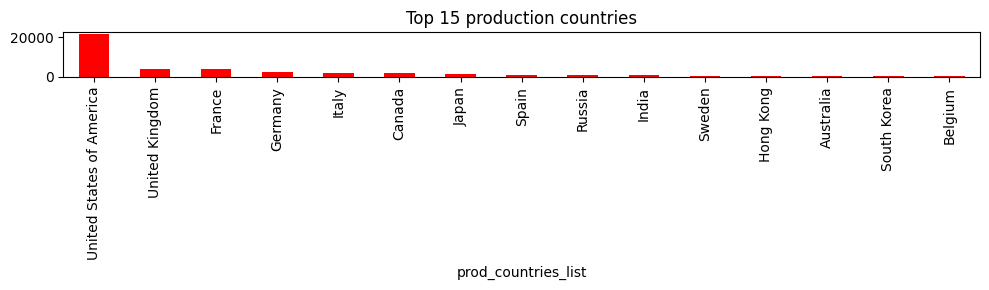

In [ ]:
import json, ast
#  Coverage
genres_exploded = movies_meta[['id','title','genres_list']].explode('genres_list')
genre_counts = genres_exploded['genres_list'].value_counts().dropna()
plt.figure(figsize=(10,4))
genre_counts.head(15).sort_values().plot(kind='barh', color='red')
plt.title("Top 15 genres")
plt.xlabel("Number of movies")
plt.tight_layout()
plt.show()

if 'original_language' in movies_meta.columns:
    lang_counts = movies_meta['original_language'].value_counts()
    plt.figure(figsize=(10,3))
    lang_counts.head(15).plot(kind='bar', color='red')
    plt.title("Top 15 original languages")
    plt.tight_layout()
    plt.show()

countries_exploded = movies_meta[['id','title','prod_countries_list']].explode('prod_countries_list')
country_counts = countries_exploded['prod_countries_list'].value_counts().dropna()
plt.figure(figsize=(10,3))
country_counts.head(15).plot(kind='bar', color='red')
plt.title("Top 15 production countries")
plt.tight_layout()
plt.show()

In [ ]:
#  Rated movies genre coverage
rated_tmdb_ids = ratings_with_meta['tmdbId'].dropna().astype(int).unique()
rated_movies = movies_meta[movies_meta['id'].isin(rated_tmdb_ids)]
rated_genres = rated_movies['genres_list'].explode().value_counts()
display(rated_genres.head(15).to_frame('count'))



,count
genres_list,
Drama,4708
Comedy,3406
Thriller,2024
Romance,1874
Action,1769
Crime,1261
Adventure,1223
Horror,922
Science Fiction,880


In [ ]:
import pandas as pd
import numpy as np
import json, ast

print("Initial shapes:")
print(f"  movies:   {movies.shape}")
print(f"  credits:  {credits.shape}")
print(f"  keywords: {keywords.shape}")
print()

#  Fix ID types
def clean_id(df, name="df"):
    before = df.shape[0]
    df["id"] = df["id"].astype(str)
    after = df.shape[0]
    print(f"{name}: before={before}, after={after}")
    return df

movies = clean_id(movies, "movies")
credits = clean_id(credits, "credits")
keywords = clean_id(keywords, "keywords")
print()

# Merge credits and keywords
before = movies.shape[0]
movies = movies.merge(credits[['id','cast','crew']], on='id', how='left')
after_credits = movies.shape[0]
print(f"Merge with credits: before={before}, after={after_credits}")

before = movies.shape[0]
movies = movies.merge(keywords[['id','keywords']], on='id', how='left')
after_keywords = movies.shape[0]
print(f"Merge with keywords: before={before}, after={after_keywords}")
print()

#  Process genres, cast, crew, keywords
movies['genres_list'] = movies['genres'].apply(lambda x: safe_parse_list_of_dicts(x, key="name"))
movies['cast_list'] = movies['cast'].apply(lambda x: safe_parse_list_of_dicts(x, key="name")[:5])  # top 5
movies['crew_list'] = movies['crew'].apply(lambda x: safe_parse_list_of_dicts(x, key="name")[:5])  # top 5
movies['keywords_list'] = movies['keywords'].apply(lambda x: safe_parse_list_of_dicts(x, key="name"))


# Combine text features
text_cols = ['overview', 'tagline']
for col in text_cols:
    if col not in movies.columns:
        movies[col] = ''

movies['text_features'] = movies[text_cols].fillna('').agg(' '.join, axis=1)

#  Keep useful columns only
movies_cleaned = movies[['id', 'title', 'genres_list', 'cast_list', 'crew_list', 'keywords_list', 'text_features']]

print("Final cleaned shape:", movies_cleaned.shape)

movies_cleaned.to_csv("movies_cleaned.csv", index=False)
print(" movies_cleaned.csv saved successfully")


Initial shapes:
  movies:   (45463, 24)
  credits:  (45476, 3)
  keywords: (46419, 2)

movies: before=45463, after=45463
credits: before=45476, after=45476
keywords: before=46419, after=46419

Merge with credits: before=45463, after=45539
Merge with keywords: before=45539, after=46629

Final cleaned shape: (46629, 7)
 movies_cleaned.csv saved successfully


task 2

Minimum votes required (m): 49.0
Global mean rating (C): 5.61

Top 10 movies by Weighted Rating:
                             title  vote_count  vote_average        WR
10357  Dilwale Dulhania Le Jayenge       661.0           9.1  8.859252
314       The Shawshank Redemption      8358.0           8.5  8.483165
837                  The Godfather      6024.0           8.5  8.476695
41402                   Your Name.      1030.0           8.5  8.368831
12541              The Dark Knight     12269.0           8.3  8.289306
2858                    Fight Club      9678.0           8.3  8.286457
292                   Pulp Fiction      8670.0           8.3  8.284891
522               Schindler's List      4436.0           8.3  8.270628
23818                     Whiplash      4376.0           8.3  8.270230
5505                 Spirited Away      3968.0           8.3  8.267207


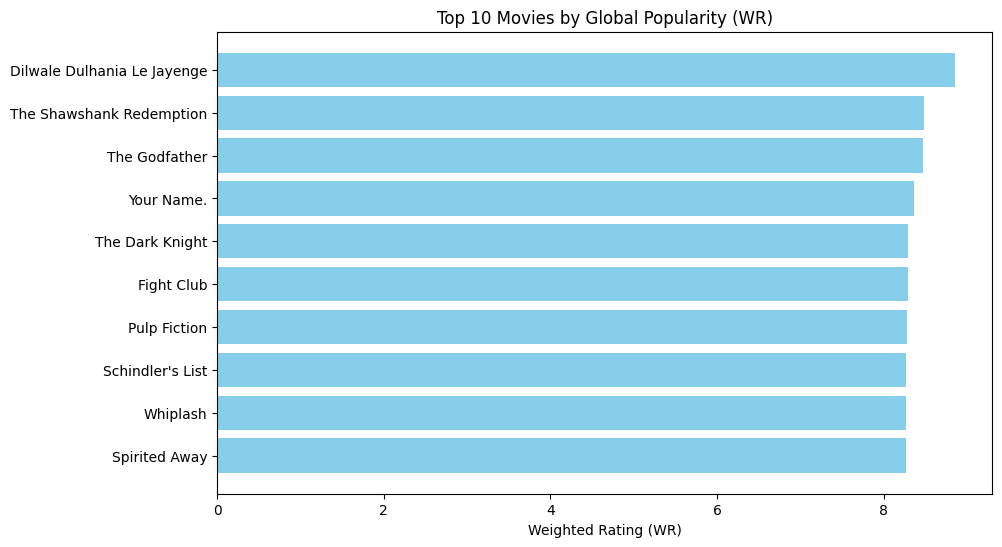


No Action movies found in the dataset.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json

# Pick title column dynamically
title_col = 'title' if 'title' in movies.columns else 'original_title'

# Calculate m (minimum votes) and C (global mean rating)
m = movies['vote_count'].quantile(0.80)
C = movies['vote_average'].mean()

# Filter movies meeting the minimum vote count
qualified = movies.loc[movies['vote_count'] >= m].copy()

# Weighted rating function
def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']
    return (v / (v + m) * R) + (m / (v + m) * C)

# Compute WR for each qualified movie
qualified['WR'] = qualified.apply(weighted_rating, axis=1)

# Sort by WR
qualified = qualified.sort_values('WR', ascending=False)

print(f"Minimum votes required (m): {m}")
print(f"Global mean rating (C): {C:.2f}")
print("\nTop 10 movies by Weighted Rating:")
print(qualified[[title_col, 'vote_count', 'vote_average', 'WR']].head(10))

# Plot Top 10 Movies by WR
top10 = qualified.head(10)
plt.figure(figsize=(10,6))
plt.barh(top10[title_col], top10['WR'], color='skyblue')
plt.xlabel("Weighted Rating (WR)")
plt.title("Top 10 Movies by Global Popularity (WR)")
plt.gca().invert_yaxis()
plt.show()

# Per-Genre Popularity Variant

# Parse genres column (assuming it's JSON-formatted strings)
def parse_genres(genre_str):
    try:
        return [g['name'] for g in json.loads(genre_str)]
    except:
        return []
movies['genres_list'] = movies['genres'].apply(parse_genres)

genre_top = {}
for genre in set(g for sublist in movies['genres_list'] for g in sublist):
    genre_movies = movies[movies['genres_list'].apply(lambda x: genre in x)]
    m_genre = genre_movies['vote_count'].quantile(0.80)
    C_genre = genre_movies['vote_average'].mean()
    qualified_genre = genre_movies[genre_movies['vote_count'] >= m_genre].copy()
    qualified_genre['WR'] = qualified_genre.apply(
        lambda x: weighted_rating(x, m_genre, C_genre), axis=1
    )
    genre_top[genre] = qualified_genre.sort_values('WR', ascending=False).head(5)

# Example output: Top 5 Action movies
if 'Action' in genre_top and not genre_top['Action'].empty:
    print("\nTop 5 Action Movies by WR:")
    print(genre_top['Action'][[title_col, "vote_count", "vote_average", "WR"]])
else:
    print("\nNo Action movies found in the dataset.")

task 3

In [ ]:

print("movies.columns")
print(movies.columns)

movies.columns
Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'keywords', 'cast', 'crew', 'genres_list',
       'keywords_list', 'cast_list', 'crew_list', 'text_features'],
      dtype='object')


In [ ]:
print("credits.columns")
print(credits.columns)

credits.columns
Index(['cast', 'crew', 'id'], dtype='object')


In [ ]:
print("keywords.columns")
print(keywords.columns)

keywords.columns
Index(['id', 'keywords'], dtype='object')


In [ ]:
print("links.columns")
print(links.columns)

links.columns
Index(['movieId', 'imdbId', 'tmdbId'], dtype='object')


In [ ]:
print("ratings.columns")
print(ratings.columns)

ratings.columns
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')


In [ ]:
movies.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'movie_key', 'imdb_id', 'original_language', 'original_title',
       'overview', 'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count', 'genres_list', 'text_features',
       'genres_text'],
      dtype='object')

In [ ]:
# Content-Based Recommender

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack


#  Normalize movie key columns
if "movie_key" not in movies.columns:
    if "movieId" in movies.columns:
        movies = movies.rename(columns={"movieId": "movie_key"})
    elif "id" in movies.columns:
        movies = movies.rename(columns={"id": "movie_key"})
    else:
        raise ValueError("movies.csv must contain a movie identifier column.")

# Ratings column
if "movieId" not in ratings.columns:
    if "movie_key" in ratings.columns:
        ratings = ratings.rename(columns={"movie_key": "movieId"})
    elif "id" in ratings.columns:
        ratings = ratings.rename(columns={"id": "movieId"})
    else:
        raise ValueError("ratings.csv must contain a movie identifier column.")

#  Keep unique movies safely
# Convert genres_list to tuple for deduplication
if "genres_list" in movies.columns:
    movies["genres_tuple"] = movies["genres_list"].apply(lambda x: tuple(eval(x)) if isinstance(x, str) else tuple(x))
else:
    movies["genres_tuple"] = ()

# If text_features missing, fallback to title + genres_text
if "text_features" not in movies.columns:
    movies["text_features"] = (movies["title"].fillna("") + " " + movies["genres_text"].fillna("")).str.strip()

movies_unique = movies.drop_duplicates(subset=["movie_key", "genres_tuple", "text_features"]).reset_index(drop=True)

#  TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies_unique["text_features"])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

#  Multi-hot encode genres
mlb = MultiLabelBinarizer(sparse_output=True)
movies_unique["genres_list"] = movies_unique["genres_list"].apply(lambda x: eval(x) if isinstance(x, str) else x)
genres_mh = mlb.fit_transform(movies_unique["genres_list"])
print(f"Multi-hot genres matrix shape: {genres_mh.shape}")

# Combine features
item_matrix = hstack([tfidf_matrix, genres_mh]).tocsr()
print(f"Combined item feature matrix shape: {item_matrix.shape}")

#  Optional SVD reduction
svd = TruncatedSVD(n_components=200, random_state=42)
item_matrix_reduced = svd.fit_transform(item_matrix)
print(f"Reduced item matrix shape: {item_matrix_reduced.shape}")

#  Map movie_key -> row index
key_to_index = pd.Series(movies_unique.index.values, index=movies_unique["movie_key"]).to_dict()

#  Build user profiles
ratings_in = ratings[ratings["movieId"].isin(key_to_index.keys())].copy()
user_profiles = {}
for user_id, group in ratings_in.groupby("userId"):
    g = group.groupby("movieId", as_index=False)["rating"].mean()
    valid = g["movieId"].isin(key_to_index.keys())
    g = g[valid]
    if g.empty:
        continue
    movie_indices = np.array([key_to_index[mid] for mid in g["movieId"].values], dtype=int)
    ratings_vec = g["rating"].values.reshape(-1, 1)
    items = item_matrix_reduced[movie_indices]
    user_mean = ratings_vec.mean()
    weighted = (ratings_vec - user_mean) * items
    profile = weighted.mean(axis=0)
    user_profiles[user_id] = profile

# Recommendation function
def recommend_for_user(user_id, top_n=10, min_profile_norm=1e-8):
    if user_id not in user_profiles:
        return pd.DataFrame({"title": [], "genres": [], "score": [], "explanation": []})

    profile = user_profiles[user_id]
    if np.linalg.norm(profile) < min_profile_norm:
        return pd.DataFrame({"title": [], "genres": [], "score": [], "explanation": []})

    sims = cosine_similarity(profile.reshape(1, -1), item_matrix_reduced).ravel()
    seen_ids = ratings_in.loc[ratings_in["userId"] == user_id, "movieId"].unique().tolist()
    if seen_ids:
        seen_indices = movies_unique.index[movies_unique["movie_key"].isin(seen_ids)]
        sims[seen_indices] = -1.0

    top_idx = np.argsort(-sims)[:top_n]
    recs = movies_unique.iloc[top_idx][["movie_key", "title", "genres_list"]].copy()
    recs["score"] = sims[top_idx]

    user_seen_rows = movies_unique[movies_unique["movie_key"].isin(seen_ids)]
    explanations = []
    for i in top_idx:
        cand_genres = set(movies_unique.iloc[i]["genres_list"])
        shared = set()
        for _, row in user_seen_rows.iterrows():
            shared = shared.union(cand_genres.intersection(set(row["genres_list"])))
        explanations.append("Genres in common: " + ", ".join(sorted(shared)) if shared else "No shared genres")
    recs["explanation"] = explanations

    recs["genres"] = recs["genres_list"].apply(lambda xs: ", ".join(xs))
    recs = recs.drop(columns=["genres_list", "movie_key"])
    return recs[["title", "genres", "score", "explanation"]]

#  Test a sample user
sample_user_id = int(ratings_in["userId"].iloc[0]) if not ratings_in.empty else None
if sample_user_id is not None:
    print(f"\nTop recommendations for user {sample_user_id}:")
    print(recommend_for_user(sample_user_id, top_n=10))
else:
    print("No overlapping movie IDs between ratings.csv and movies.csv found.")


TF-IDF matrix shape: (45433, 5000)
Multi-hot genres matrix shape: (45433, 20)
Combined item feature matrix shape: (45433, 5020)
Reduced item matrix shape: (45433, 200)

Top recommendations for user 1:
                               title           genres     score  \
4588                  American Pie 2  Comedy, Romance  0.648734   
21106                American Idiots  Comedy, Romance  0.646933   
39912                American Fusion  Comedy, Romance  0.645989   
4936                  American Adobo  Comedy, Romance  0.644111   
11898               American Friends  Comedy, Romance  0.631500   
6436                American Wedding  Comedy, Romance  0.592644   
40639         All Roads Lead to Rome  Comedy, Romance  0.579327   
42572       Everybody Loves Somebody  Romance, Comedy  0.579142   
12924  Everybody Wants to Be Italian  Comedy, Romance  0.578977   
274                   Miami Rhapsody  Comedy, Romance  0.578811   

                             explanation  
4588   Genres in c

task 4

In [ ]:
!pip install scikit-surprise


In [ ]:
# Collaborative Filtering (Surprise)
import pandas as pd
from surprise import Dataset, Reader, SVD, KNNBasic, accuracy
from surprise.model_selection import train_test_split

# Ensure column consistency
if "movie_key" in movies.columns:
    movies = movies.rename(columns={"movie_key": "movieId"})

# Surprise Dataset
reader = Reader(rating_scale=(ratings["rating"].min(), ratings["rating"].max()))
data = Dataset.load_from_df(ratings[["userId", "movieId", "rating"]], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

#  Neighborhood-based CF
# User-based kNN (cosine similarity)
sim_options_user = {"name": "cosine", "user_based": True}
knn_user = KNNBasic(k=20, sim_options=sim_options_user)
knn_user.fit(trainset)
preds_user = knn_user.test(testset)
rmse_user = accuracy.rmse(preds_user)
mae_user = accuracy.mae(preds_user)

# Item-based kNN (cosine similarity)
sim_options_item = {"name": "cosine", "user_based": False}
knn_item = KNNBasic(k=20, sim_options=sim_options_item)
knn_item.fit(trainset)
preds_item = knn_item.test(testset)
rmse_item = accuracy.rmse(preds_item)
mae_item = accuracy.mae(preds_item)

# Matrix Factorization (SVD)
# SVD: regularized latent-factor model
# r_ui ≈ μ + b_u + b_i + p_u^T q_i
svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd.fit(trainset)
preds_svd = svd.test(testset)
rmse_svd = accuracy.rmse(preds_svd)
mae_svd = accuracy.mae(preds_svd)

#  Top-N recommendations for a user
def top_n_recommendations(algo, user_id, n=10):
    """Return top-n recommended movies for a given user_id."""
    all_movie_ids = ratings["movieId"].unique()
    predictions = [algo.predict(user_id, mid) for mid in all_movie_ids]
    predictions.sort(key=lambda x: x.est, reverse=True)
    top_n = predictions[:n]
    results = []
    for pred in top_n:
        title = movies.loc[movies["movieId"] == pred.iid, "title"].values
        title = title[0] if len(title) > 0 else str(pred.iid)
        results.append((title, pred.est))
    return results

# Example: Top-10 recommendations for a sample user
sample_user = ratings["userId"].iloc[0]
recommendations = top_n_recommendations(svd, sample_user, n=10)

print(f"\nTop 10 recommendations for user {sample_user}:")
for title, score in recommendations:
    print(f"Movie: {title}, Predicted rating: {score:.2f}")


Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.9962
MAE:  0.7699
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0223
MAE:  0.8007
RMSE: 0.8990
MAE:  0.6928

Top 10 recommendations for user 1:
Movie: The Million Dollar Hotel, Predicted rating: 3.86
Movie: 5 Card Stud, Predicted rating: 3.79
Movie: 5952, Predicted rating: 3.78
Movie: Broken Blossoms, Predicted rating: 3.76
Movie: 1136, Predicted rating: 3.75
Movie: 1221, Predicted rating: 3.74
Movie: Mission: Impossible, Predicted rating: 3.73
Movie: 1172, Predicted rating: 3.73
Movie: Galaxy Quest, Predicted rating: 3.73
Movie: 1196, Predicted rating: 3.68


task 5

In [ ]:
# Hybrid Recommender
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def hybrid_recommend(user_id, alpha=0.5, top_n=10, min_profile_norm=1e-8):
    """
    Generate hybrid recommendations by blending CF and CB scores:
    shyb(u,i) = alpha * sCF(u,i) + (1-alpha) * sCB(u,i)

    Parameters:
    - user_id: int, ID of the user
    - alpha: float, weight of CF score (0..1)
    - top_n: int, number of recommendations
    """
    if user_id not in user_profiles:
        return pd.DataFrame(columns=["title", "genres", "score", "explanation"])

    #  CB score
    profile = user_profiles[user_id]
    if np.linalg.norm(profile) < min_profile_norm:
        return pd.DataFrame(columns=["title", "genres", "score", "explanation"])
    s_cb = cosine_similarity(profile.reshape(1, -1), item_matrix_reduced).ravel()

    #  CF score
    movie_ids = movies_unique["movie_key"].values
    s_cf = np.array([svd.predict(user_id, mid).est for mid in movie_ids])

    #  Hybrid
    s_hyb = alpha * s_cf + (1 - alpha) * s_cb

    #  Exclude already seen movies
    seen_ids = ratings_in.loc[ratings_in["userId"] == user_id, "movieId"].unique()
    seen_indices = movies_unique.index[movies_unique["movie_key"].isin(seen_ids)]
    s_hyb[seen_indices] = -1.0

    #  Top-N recommendations
    top_idx = np.argsort(-s_hyb)[:top_n]
    recs = movies_unique.iloc[top_idx][["movie_key", "title", "genres_list"]].copy()
    recs["score"] = s_hyb[top_idx]

    #  Explanation: shared genres with already seen movies
    user_seen_rows = movies_unique[movies_unique["movie_key"].isin(seen_ids)]
    explanations = []
    for i in top_idx:
        cand_genres = set(movies_unique.iloc[i]["genres_list"])
        shared = set()
        for _, row in user_seen_rows.iterrows():
            shared = shared.union(cand_genres.intersection(set(row["genres_list"])))
        explanations.append("Genres in common: " + ", ".join(sorted(shared)) if shared else "No shared genres")
    recs["explanation"] = explanations

    # Pretty genres
    recs["genres"] = recs["genres_list"].apply(lambda xs: ", ".join(xs))
    recs = recs.drop(columns=["genres_list", "movie_key"])
    return recs[["title", "genres", "score", "explanation"]]

# Example usage
sample_user = int(ratings_in["userId"].iloc[0])
alpha_val = 0.6  # weight for CF; tune this on validation set
top_recs = hybrid_recommend(sample_user, alpha=alpha_val, top_n=10)
print(f"\nTop 10 hybrid recommendations for user {sample_user}:")
print(top_recs)



Top 10 hybrid recommendations for user 1:
                          title                           genres     score  \
3057               Galaxy Quest  Comedy, Family, Science Fiction  2.323190   
8736            Cousin, Cousine                  Romance, Comedy  2.303211   
2958              Irma la Douce                  Comedy, Romance  2.293899   
11919            License to Wed                           Comedy  2.279503   
534        Sleepless in Seattle           Comedy, Drama, Romance  2.278327   
5294                5 Card Stud        Action, Western, Thriller  2.273393   
1497   My Best Friend's Wedding                  Comedy, Romance  2.265763   
6835            Broken Blossoms                   Drama, Romance  2.254338   
2064                Beetlejuice                  Fantasy, Comedy  2.244547   
638         Mission: Impossible      Adventure, Action, Thriller  2.239605   

                                    explanation  
3057                   Genres in common: Comedy 

task 6

/tmp/ipython-input-3178828227.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'timestamp': pd.date_range('2023-01-01', periods=1000, freq='H')


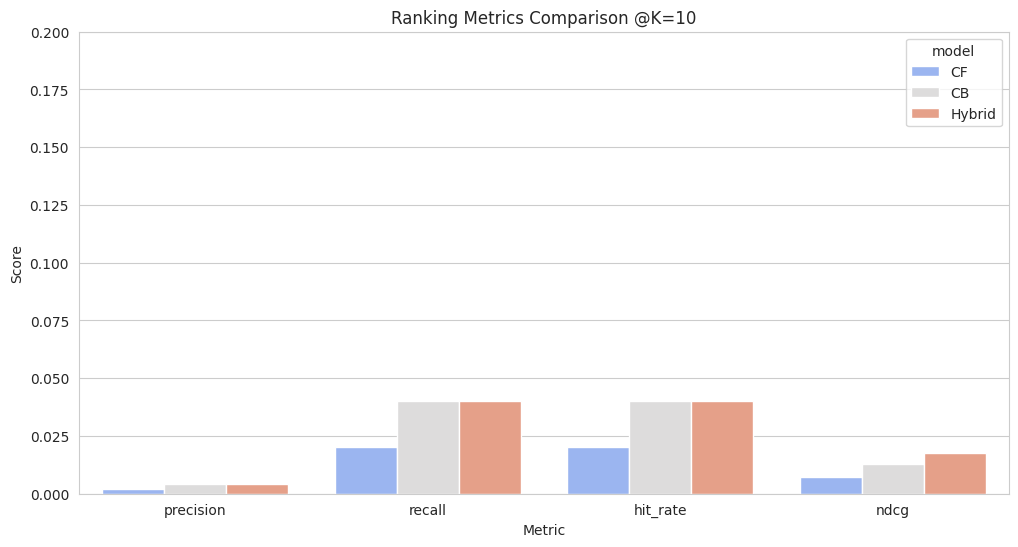

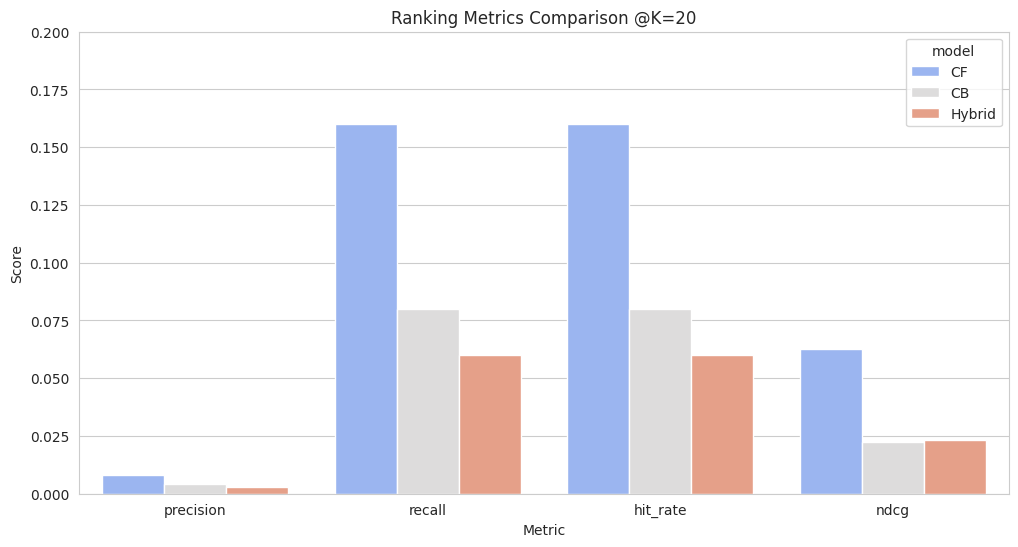

    model  Catalog Coverage@10  Novelty@10  Intra-list Diversity@10
0      CF                0.965    0.282105                 0.510808
1      CB                0.925    0.282244                 0.508363
2  Hybrid                0.935    0.287527                 0.481467


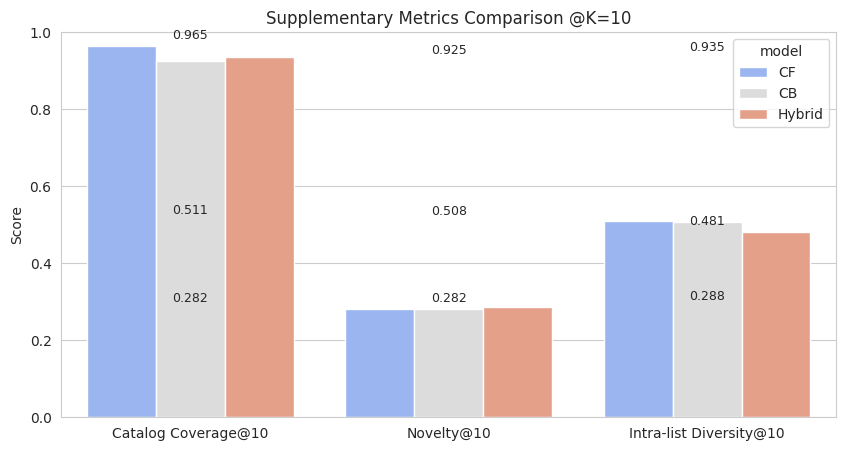

In [ ]:
#  Hybrid + CF + CB Recommender Evaluation with Supplementary Metrics
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.metrics import ndcg_score
import matplotlib.pyplot as plt
import seaborn as sns

#  Generate Sample Dataset
np.random.seed(42)
n_users = 50
n_items = 200

ratings = pd.DataFrame({
    'userId': np.random.randint(1, n_users+1, 1000),
    'movieId': np.random.randint(1, n_items+1, 1000),
    'rating': np.random.randint(1, 6, 1000),
    'timestamp': pd.date_range('2023-01-01', periods=1000, freq='H')
})
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'])
ratings = ratings.sort_values(['userId', 'timestamp'])

# Leave-One-Out split per user
loo_test = ratings.groupby('userId').tail(1)
train_df = ratings.drop(loo_test.index)
all_items = ratings['movieId'].unique()

#  Dummy CF & CB Predictions
def cf_predict(user, item):
    return np.random.rand()

cb_preds = {(user, item): np.random.rand()
            for user in train_df['userId'].unique()
            for item in train_df['movieId'].unique()}

def hybrid_score(user, item, alpha=0.5):
    return alpha * cf_predict(user, item) + (1-alpha) * cb_preds.get((user, item), 0.0)

#  Top-K Recommendation Functions
def get_top_k_cf(user, train_df, all_items, K=10):
    seen = set(train_df[train_df.userId==user]['movieId'])
    candidates = [i for i in all_items if i not in seen]
    scores = [(i, cf_predict(user, i)) for i in candidates]
    return [i for i, _ in sorted(scores, key=lambda x: x[1], reverse=True)[:K]]

def get_top_k_cb(user, train_df, all_items, K=10):
    seen = set(train_df[train_df.userId==user]['movieId'])
    candidates = [i for i in all_items if i not in seen]
    scores = [(i, cb_preds.get((user, i), 0.0)) for i in candidates]
    return [i for i, _ in sorted(scores, key=lambda x: x[1], reverse=True)[:K]]

def get_top_k_hybrid(user, train_df, all_items, alpha=0.5, K=10):
    seen = set(train_df[train_df.userId==user]['movieId'])
    candidates = [i for i in all_items if i not in seen]
    scores = [(i, hybrid_score(user, i, alpha)) for i in candidates]
    return [i for i, _ in sorted(scores, key=lambda x: x[1], reverse=True)[:K]]

#  Ranking Metrics
def precision_at_k(recs, relevant):
    return len(set(recs) & set(relevant)) / len(recs)

def recall_at_k(recs, relevant):
    return len(set(recs) & set(relevant)) / len(relevant)

def hit_rate_at_k(recs, relevant):
    return int(len(set(recs) & set(relevant)) > 0)

def ndcg_at_k(recs, relevant, K):
    y_true = [1 if i in relevant else 0 for i in recs]
    y_score = list(range(len(recs), 0, -1))
    return ndcg_score([y_true], [y_score])

def bootstrap_ci(data, n_boot=1000, ci=95):
    data = np.array(data)
    boot_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lower = np.percentile(boot_means, (100-ci)/2)
    upper = np.percentile(boot_means, 100-(100-ci)/2)
    return np.mean(data), lower, upper


#  Evaluate CF, CB, Hybrid Ranking Metrics-
models = {'CF': get_top_k_cf, 'CB': get_top_k_cb, 'Hybrid': get_top_k_hybrid}
Ks = [10, 20]
metrics_comp = []

for model_name, func in models.items():
    for K in Ks:
        precision_list, recall_list, hit_list, ndcg_list = [], [], [], []
        for user in loo_test['userId'].unique():
            relevant = loo_test[loo_test.userId==user]['movieId'].tolist()
            recs = func(user, train_df, all_items, K=K)
            precision_list.append(precision_at_k(recs, relevant))
            recall_list.append(recall_at_k(recs, relevant))
            hit_list.append(hit_rate_at_k(recs, relevant))
            ndcg_list.append(ndcg_at_k(recs, relevant, K))
        for metric_name, values in zip(['precision','recall','hit_rate','ndcg'], [precision_list, recall_list, hit_list, ndcg_list]):
            mean, lower, upper = bootstrap_ci(values)
            metrics_comp.append({
                'model': model_name,
                'K': K,
                'metric': metric_name,
                'mean': mean,
                'CI_lower': lower,
                'CI_upper': upper
            })

comp_df = pd.DataFrame(metrics_comp)

#  Ranking Metrics Plots
for K in Ks:
    plt.figure(figsize=(12,6))
    sns.set_style("whitegrid")
    sns.barplot(
        x='metric',
        y='mean',
        hue='model',
        data=comp_df[comp_df.K==K],
        palette="coolwarm"
    )
    plt.title(f'Ranking Metrics Comparison @K={K}')
    plt.ylabel('Score')
    plt.xlabel('Metric')
    plt.ylim(0, 0.2)
    plt.show()

#  Supplementary Metrics for All Models
def compute_supp_metrics(func, train_df, all_items, loo_test, K=10):
    recommended_items = set()
    for user in loo_test['userId'].unique():
        recommended_items.update(func(user, train_df, all_items, K=K))
    catalog_coverage = len(recommended_items) / len(all_items)

    popularity = train_df['movieId'].value_counts().to_dict()
    novelty_scores = []
    diversity_scores = []

    for user in loo_test['userId'].unique():
        recs = func(user, train_df, all_items, K=K)
        novelty_scores.append(np.mean([1/popularity.get(i,1) for i in recs]))
        if len(recs) < 2:
            diversity_scores.append(0)
            continue
        sims = [np.random.rand() for _ in range(len(recs)*(len(recs)-1)//2)]
        diversity_scores.append(np.mean([1-s for s in sims]))
    return {
        'Catalog Coverage@10': catalog_coverage,
        'Novelty@10': np.mean(novelty_scores),
        'Intra-list Diversity@10': np.mean(diversity_scores)
    }

supp_metrics_all = {model: compute_supp_metrics(func, train_df, all_items, loo_test, K=10) for model, func in models.items()}

# Convert to DataFrame for plotting
supp_df = pd.DataFrame(supp_metrics_all).T.reset_index().rename(columns={'index':'model'})
print(supp_df)

#Supplementary Metrics Plot
plt.figure(figsize=(10,5))
sns.set_style("whitegrid")
supp_df_melt = supp_df.melt(id_vars='model', var_name='metric', value_name='score')
sns.barplot(x='metric', y='score', hue='model', data=supp_df_melt, palette="coolwarm")

# Add value annotations
for i, row in supp_df_melt.iterrows():
    plt.text(i % 3, row['score'] + 0.01, f"{row['score']:.3f}", ha='center', va='bottom', fontsize=9)

plt.ylim(0, 1)
plt.title('Supplementary Metrics Comparison @K=10')
plt.ylabel('Score')
plt.xlabel('')
plt.show()


In [ ]:
import pickle

with open("tfidf_vectorizer1.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("tfidf_matrix1.pkl", "wb") as f:
    pickle.dump(tfidf_matrix, f)